<a href="https://colab.research.google.com/github/kapilk75/SmartWater01/blob/main/smarwater_demoSparc_07042026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================================================
# GOOGLE COLAB READY - WATER QUALITY DATASET ANALYSIS
# Includes:
# 1. Safe date parsing
# 2. Imputation
# 3. Aesthetic matplotlib visuals
# 4. KDE plots
# 5. Interactive Plotly charts
# 6. Map visualization (if lat/lon available)
# =========================================================

### ---------------------------
#### Install / import packages
### ---------------------------

In [2]:

!pip -q install openpyxl plotly scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from IPython.display import display

# ---------------------------
# Load dataset
# ---------------------------
url = "https://raw.githubusercontent.com/kapilk75/SmartWater01/main/workshop_250_rows.xlsx"
df = pd.read_excel(url)

print("Initial Dataset Shape:", df.shape)
display(df.head())

# ---------------------------
# Detect and convert date-like columns
# ---------------------------
possible_date_cols = [col for col in df.columns if "date" in col.lower()]

for col in possible_date_cols:
    df[col] = pd.to_datetime(df[col], format="%d/%m/%Y", errors="coerce")

print("\nDetected Date Columns:", possible_date_cols if possible_date_cols else "None")

Initial Dataset Shape: (250, 139)


,ec5_uuid_survey,created_at_survey,uploaded_at_survey,created_by_survey,title_survey,1_Date_Autoset_click,lat_2_Location_Click_Upd,long_2_Location_Click_Upd,accuracy_2_Location_Click_Upd,UTM_Northing_2_Location_Click_Upd,...,created_at,uploaded_at,created_by,title,112_Date_Autoset_cli,113_Time_Autoset_cli,114_Sample_No,115_Presence_of_Ecol,116_Presence_of_Tota,117_Photo_of_Bio_Kit
0,33cc0843-2087-4ad5-99c5-e3ade8a26322,2025-05-22T07:15:26.000Z,2025-05-22T10:13:46.000Z,na22b074@smail.iitm.ac.in,Tk22051239,22/05/2025,12.983787,80.241864,4.0,1435465.0,...,2025-05-22T09:58:46.000Z,2025-05-22T10:13:50.000Z,na22b074@smail.iitm.ac.in,Sample 6,22/05/2025,15:28:25,Sample 6,Yes,Yes,287e9de1-8031-4d38-bfc2-162d9b7f216a_174790792...
1,23f7db67-a94f-4490-890a-9c3cfe5ae6a6,2025-05-22T06:47:43.000Z,2025-05-22T09:59:26.000Z,na22b084@smail.iitm.ac.in,IJ22051150,22/05/2025,12.981735,80.240876,4.0,1435238.0,...,2025-05-22T09:53:58.000Z,2025-05-22T09:59:29.000Z,na22b084@smail.iitm.ac.in,Sample 8,22/05/2025,15:23:42,Sample 8,No,No,2a22a5f6-99aa-491a-9a9c-2a3e362c813f_174790763...
2,fb708e0b-da63-4a17-8167-019c755773e2,2025-05-21T07:06:42.000Z,2025-05-22T09:59:02.000Z,na22b084@smail.iitm.ac.in,IJ21051130,21/05/2025,12.943463,80.208609,4.0,1431016.0,...,2025-05-22T09:36:28.000Z,2025-05-22T09:59:06.000Z,na22b084@smail.iitm.ac.in,Sample 1,22/05/2025,15:05:41,Sample 1,No,No,8ffa2528-7723-469f-b74d-adb0c504a54a_174790658...
3,e530531d-8173-40fd-8c22-d48287164577,2025-05-21T07:09:43.000Z,2025-05-22T09:58:39.000Z,na22b084@smail.iitm.ac.in,IJ21051230,21/05/2025,12.967963,80.207516,4.0,1433726.0,...,2025-05-22T09:39:14.000Z,2025-05-22T09:58:42.000Z,na22b084@smail.iitm.ac.in,Sample 2,22/05/2025,15:08:23,Sample 2,No,No,e187d0e5-2d99-4b87-b020-7c197569b4b9_174790681...
4,3ebcb3a2-2f47-4b9b-861d-858ab00a8554,2025-05-05T12:21:46.000Z,2025-05-08T14:26:27.000Z,rabinrajanj@gmail.com,RR05051745,2025-05-05 00:00:00,8.563460,76.951780,13.0,947135.0,...,2025-05-08T14:26:12.000Z,2025-05-08T14:26:31.000Z,rabinrajanj@gmail.com,Sample 1,08/05/2025,19:55:49,Sample 1,No,No,d6b6e674-7c22-4e23-abce-22d1e7446313_174671436...



Detected Date Columns: ['1_Date_Autoset_click', '93_Date_Autoset_clic', '112_Date_Autoset_cli']


In [3]:
# ---------------------------
# Detect column types
# ---------------------------
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

# ---------------------------
# Missing-value summary before imputation
# ---------------------------
missing_before = df.isnull().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)

print("\nMissing Values Before Imputation:")
display(missing_before.to_frame("Missing Count") if len(missing_before) > 0 else pd.DataFrame({"Info": ["No missing values found"]}))




Missing Values Before Imputation:


,Missing Count
"55_Specify, if others or added materials (Empty)",250
26_If others (specify),248
27_Time (Autoset; Just touch next) (Mostly empty),248
33_If_others_specify(Mostly),247
21_If others (specify),245
...,...
accuracy_2_Location_Click_Upd,2
long_2_Location_Click_Upd,2
lat_2_Location_Click_Upd,2
104_pH,1


In [4]:
# ---------------------------
# Imputation
# Numeric -> median
# Categorical -> mode
# ---------------------------
imputation_log = []

for col in numeric_cols:
    missing_count = int(df[col].isnull().sum())
    if missing_count > 0:
        median_val = df[col].median()
        if pd.isnull(median_val):
            df[col] = df[col].fillna(0)
            strategy = "Filled with 0 (all values missing)"
        else:
            df[col] = df[col].fillna(median_val)
            strategy = f"Median ({round(float(median_val), 3)})"
        imputation_log.append((col, missing_count, strategy))

for col in categorical_cols:
    missing_count = int(df[col].isnull().sum())
    if missing_count > 0:
        mode_series = df[col].mode(dropna=True)
        if not mode_series.empty:
            mode_val = mode_series.iloc[0]
            df[col] = df[col].fillna(mode_val)
            strategy = f"Mode ({mode_val})"
        else:
            df[col] = df[col].fillna("Unknown")
            strategy = "Filled with Unknown"
        imputation_log.append((col, missing_count, strategy))

print("\nRemaining Missing Values After Imputation:", int(df.isnull().sum().sum()))

if imputation_log:
    imputation_df = pd.DataFrame(imputation_log, columns=["Column", "Missing Count", "Strategy Used"])
    print("\nImputation Summary:")
    display(imputation_df)
else:
    print("\nNo imputation was needed.")


Remaining Missing Values After Imputation: 0

Imputation Summary:


,Column,Missing Count,Strategy Used
0,lat_2_Location_Click_Upd,2,Median (12.919)
1,long_2_Location_Click_Upd,2,Median (80.116)
2,accuracy_2_Location_Click_Upd,2,Median (5.0)
3,UTM_Northing_2_Location_Click_Upd,2,Median (1428294.0)
4,UTM_Easting_2_Location_Click_Upd,2,Median (572568.0)
...,...,...,...
94,88_Did you notice any religious activity?(Empty),148,Mode (No)
95,89_Presence of farming lands within 1 km(Empty),148,Mode (No)
96,90_Presence of industries within 1 km(Empty),148,Mode (No)
97,91_Take a picture of the water source(Empty),160,Mode (f1c1f69a-04eb-4f33-9987-b47817231a5f_174...


In [5]:
# ---------------------------
# Statistical summary
# ---------------------------
if numeric_cols:
    summary_df = df[numeric_cols].describe().T
    print("\nStatistical Summary:")
    display(summary_df)



Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
lat_2_Location_Click_Upd,250.0,1.380537e+01,5.340968,0.764883,1.107290e+01,1.291860e+01,1.309102e+01,3.214061e+01
long_2_Location_Click_Upd,250.0,7.738412e+01,10.609886,34.023266,7.714038e+01,8.011632e+01,8.024181e+01,9.179571e+01
accuracy_2_Location_Click_Upd,250.0,2.708800e+01,142.345189,1.000000,4.000000e+00,5.000000e+00,1.300000e+01,1.659000e+03
UTM_Northing_2_Location_Click_Upd,250.0,1.526854e+06,591074.187265,84556.000000,1.224845e+06,1.428294e+06,1.447314e+06,3.557439e+06
UTM_Easting_2_Location_Click_Upd,250.0,5.806379e+05,149206.192265,324297.000000,4.128798e+05,5.725680e+05,7.326800e+05,8.003300e+05
17_Number of children under the age of 5 in your home,250.0,1.100000e+00,12.652047,-1.000000,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+02
"55_Specify, if others or added materials (Empty)",250.0,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
96_Total_Chlorine_mg,250.0,1.000000e-01,0.740400,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+01
97_Free_Chlorine_mgL,250.0,4.600000e-02,0.321399,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
98_Hardness_mgL,250.0,2.071400e+02,174.249165,0.000000,2.500000e+01,1.200000e+02,4.250000e+02,4.250000e+02


In [7]:
# ---------------------------
# Derived feature: Simple WQI
# ---------------------------
wqi_features = [c for c in ["pH", "TDS", "Turbidity", "DO"] if c in df.columns]

if len(wqi_features) >= 2:
    norm_df = df[wqi_features].copy()

    for col in wqi_features:
        col_min = norm_df[col].min()
        col_max = norm_df[col].max()
        if pd.notnull(col_min) and pd.notnull(col_max) and col_max != col_min:
            norm_df[col] = (norm_df[col] - col_min) / (col_max - col_min)
        else:
            norm_df[col] = 0.0

    df["WQI_Simple"] = norm_df.mean(axis=1)

In [8]:
# ---------------------------
# Aesthetic settings for matplotlib
# ---------------------------
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "figure.figsize": (12, 7),
    "axes.titlesize": 18,
    "axes.labelsize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "font.size": 12
})

# For wide datasets, use limited subsets for readable charts
plot_numeric_cols = numeric_cols[:12]
density_cols = numeric_cols[:5]

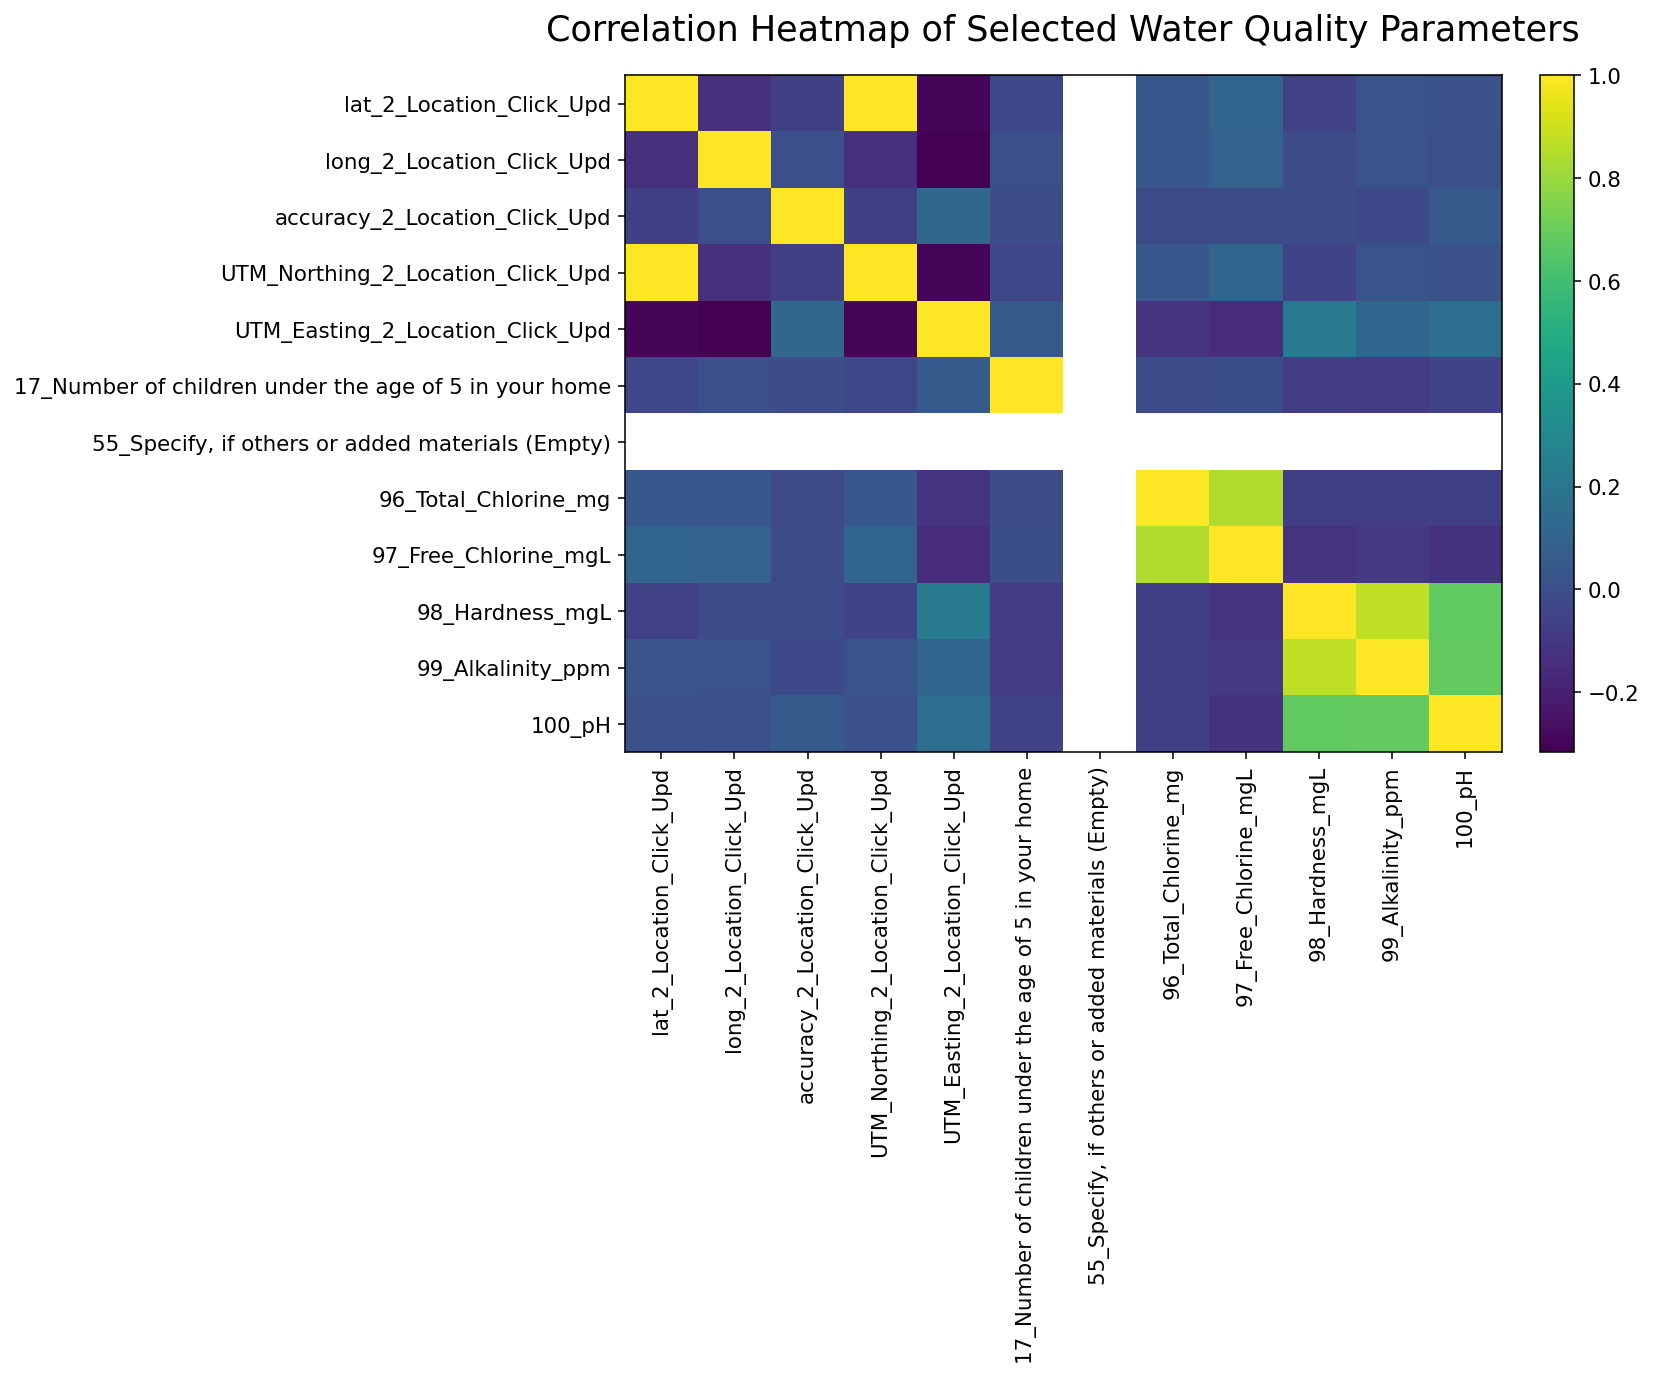

In [9]:
# =========================================================
# 1. CORRELATION HEATMAP - MATPLOTLIB
# =========================================================
if len(plot_numeric_cols) > 1:
    corr = df[plot_numeric_cols].corr()

    fig, ax = plt.subplots(figsize=(12, 10))
    cax = ax.imshow(corr, aspect="auto")
    fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticklabels(corr.columns)

    ax.set_title("Correlation Heatmap of Selected Water Quality Parameters", pad=18)
    plt.tight_layout()
    plt.show()

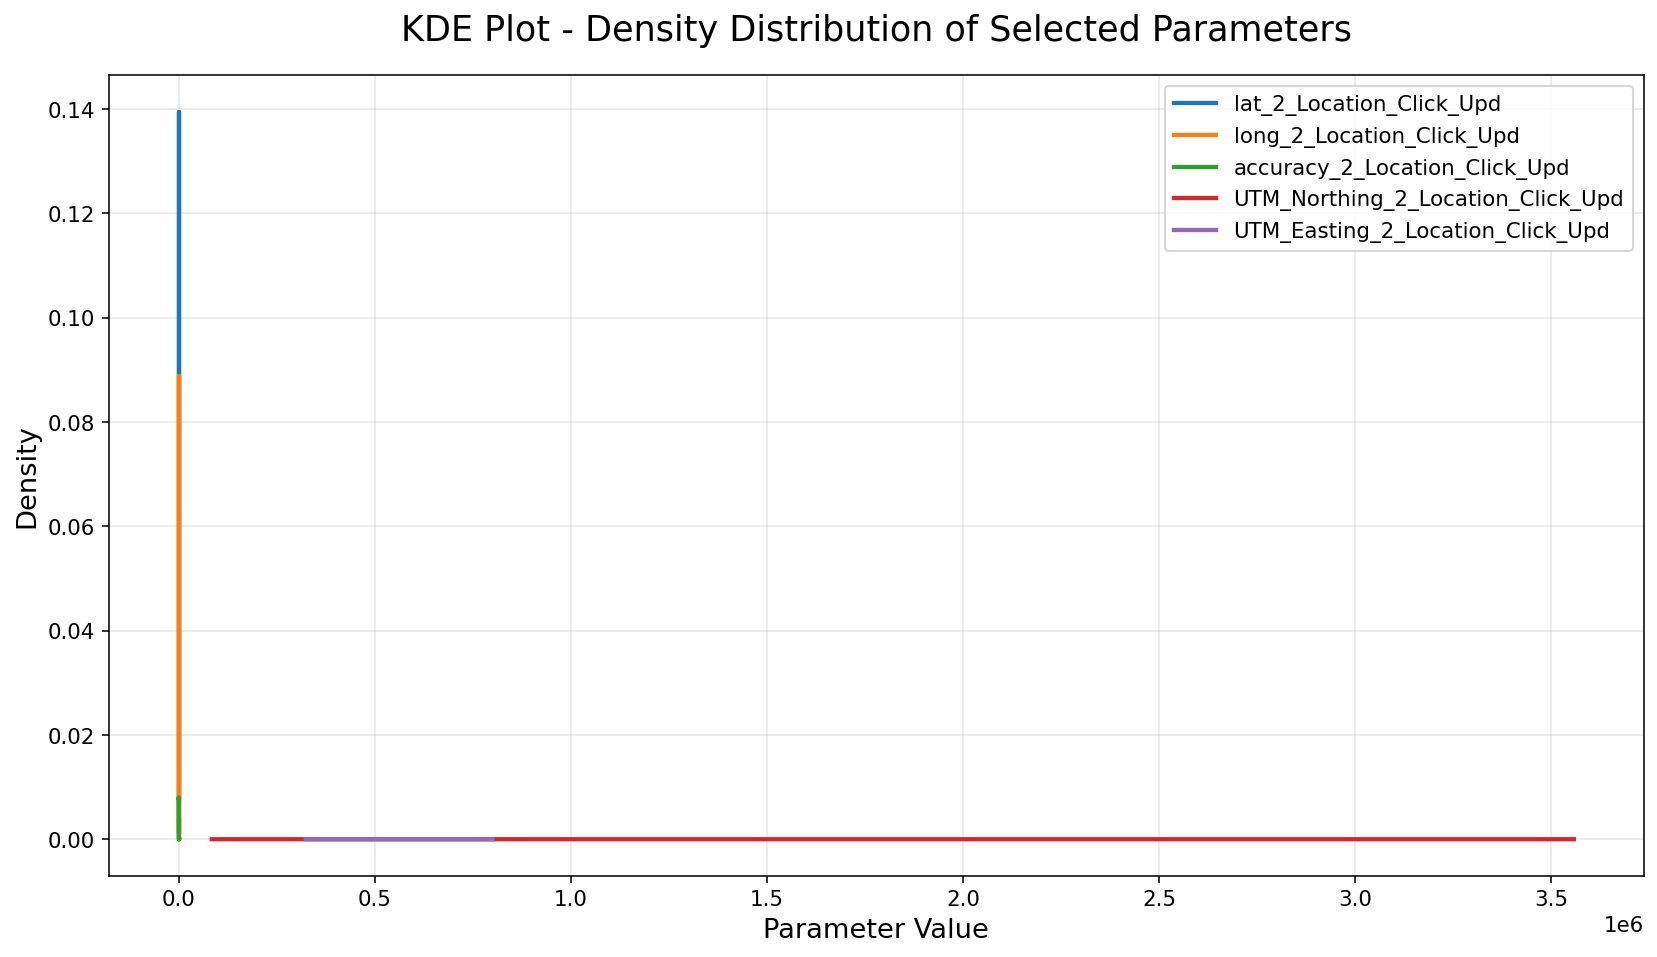

In [12]:
# =========================================================
# 2. KDE PLOTS - MATPLOTLIB
# =========================================================
if len(density_cols) > 0:
    fig, ax = plt.subplots(figsize=(12, 7))

    for col in density_cols:
        series = df[col].dropna()
        if len(series) > 1 and series.nunique() > 1:
            x_grid = np.linspace(series.min(), series.max(), 300)
            kde = gaussian_kde(series)
            ax.plot(x_grid, kde(x_grid), linewidth=2.2, label=col)

    ax.set_title("KDE Plot - Density Distribution of Selected Parameters", pad=18)
    ax.set_xlabel("Parameter Value")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [13]:
# =========================================================
# 3. SCATTER PLOT - MATPLOTLIB
# =========================================================
scatter_x = "TDS" if "TDS" in df.columns else None
scatter_y = "Conductivity" if "Conductivity" in df.columns else None

if scatter_x and scatter_y:
    fig, ax = plt.subplots(figsize=(11, 7))
    ax.scatter(df[scatter_x], df[scatter_y], alpha=0.7, s=40)

    ax.set_title(f"{scatter_x} vs {scatter_y}", pad=18)
    ax.set_xlabel(scatter_x)
    ax.set_ylabel(scatter_y)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


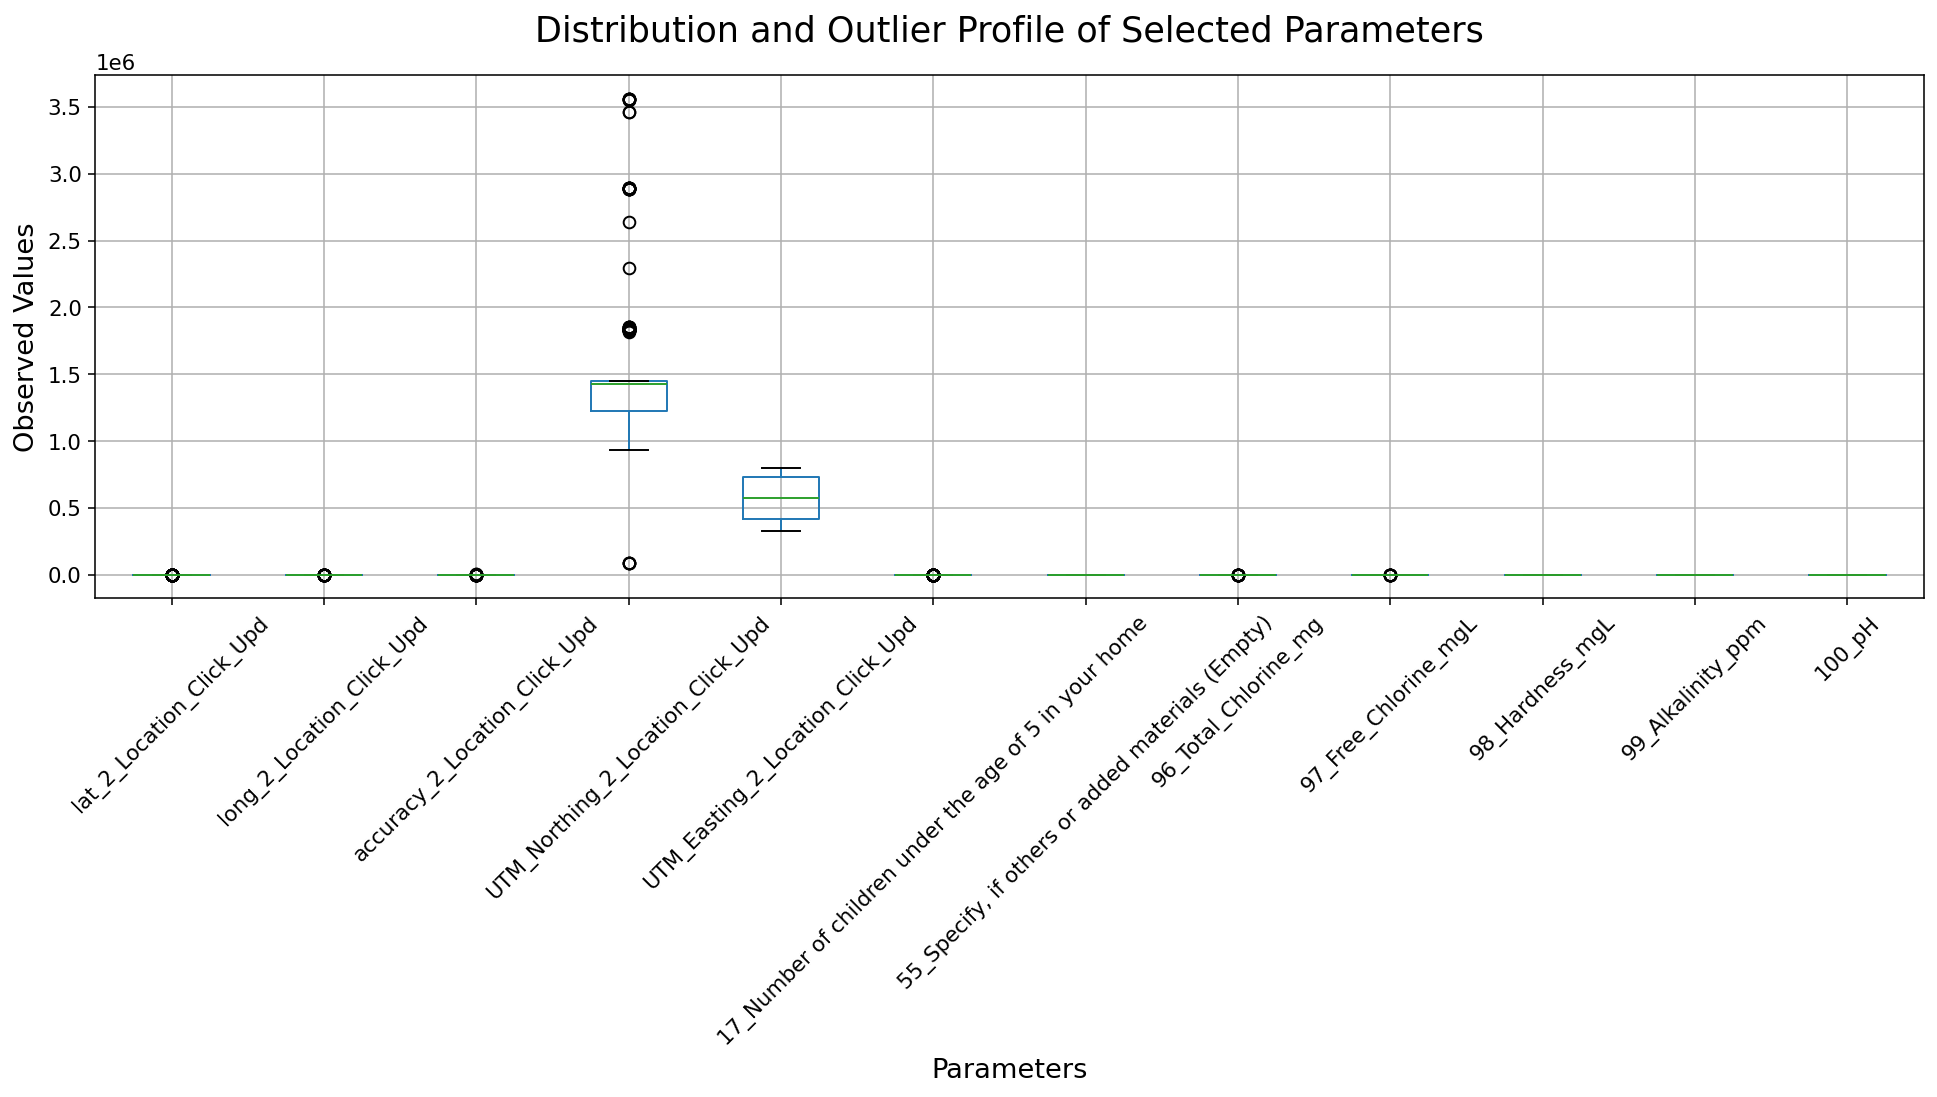

In [14]:
# =========================================================
# 4. BOX PLOT - MATPLOTLIB
# =========================================================
if len(plot_numeric_cols) > 0:
    fig, ax = plt.subplots(figsize=(14, 8))
    df[plot_numeric_cols].boxplot(ax=ax, rot=45)

    ax.set_title("Distribution and Outlier Profile of Selected Parameters", pad=18)
    ax.set_xlabel("Parameters")
    ax.set_ylabel("Observed Values")
    plt.tight_layout()
    plt.show()

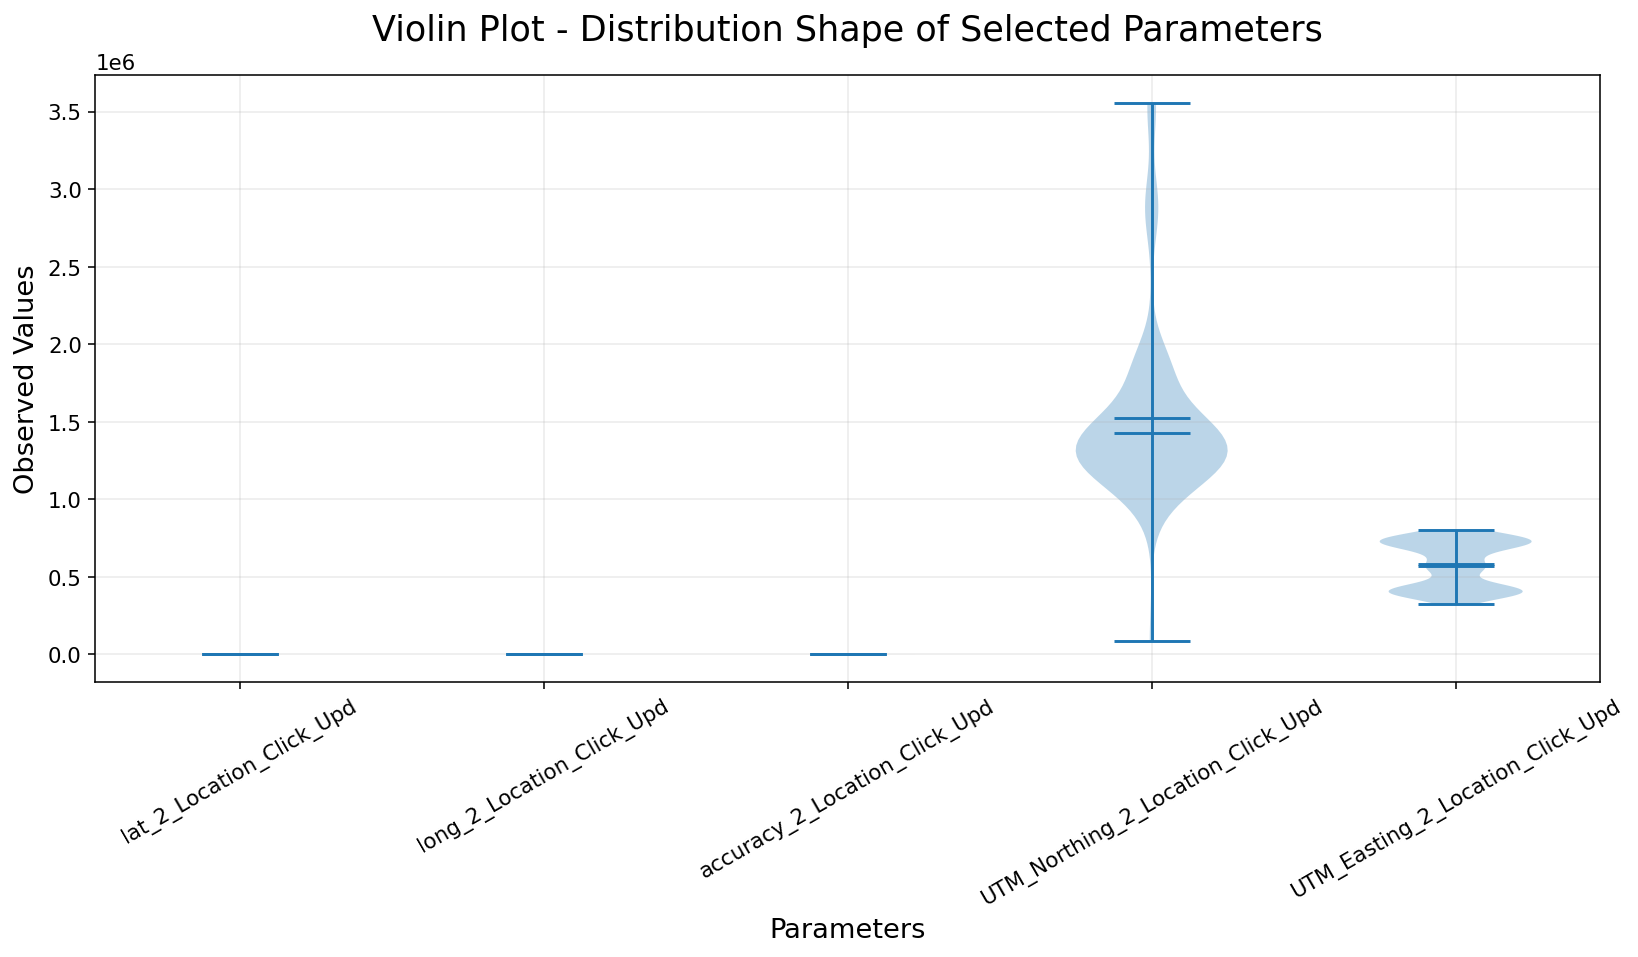

In [15]:
# =========================================================
# 5. VIOLIN PLOT - MATPLOTLIB
# =========================================================
if len(density_cols) > 0:
    violin_data = [df[col].dropna() for col in density_cols]

    fig, ax = plt.subplots(figsize=(12, 7))
    ax.violinplot(violin_data, showmeans=True, showmedians=True)

    ax.set_xticks(range(1, len(density_cols) + 1))
    ax.set_xticklabels(density_cols, rotation=30)
    ax.set_title("Violin Plot - Distribution Shape of Selected Parameters", pad=18)
    ax.set_xlabel("Parameters")
    ax.set_ylabel("Observed Values")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

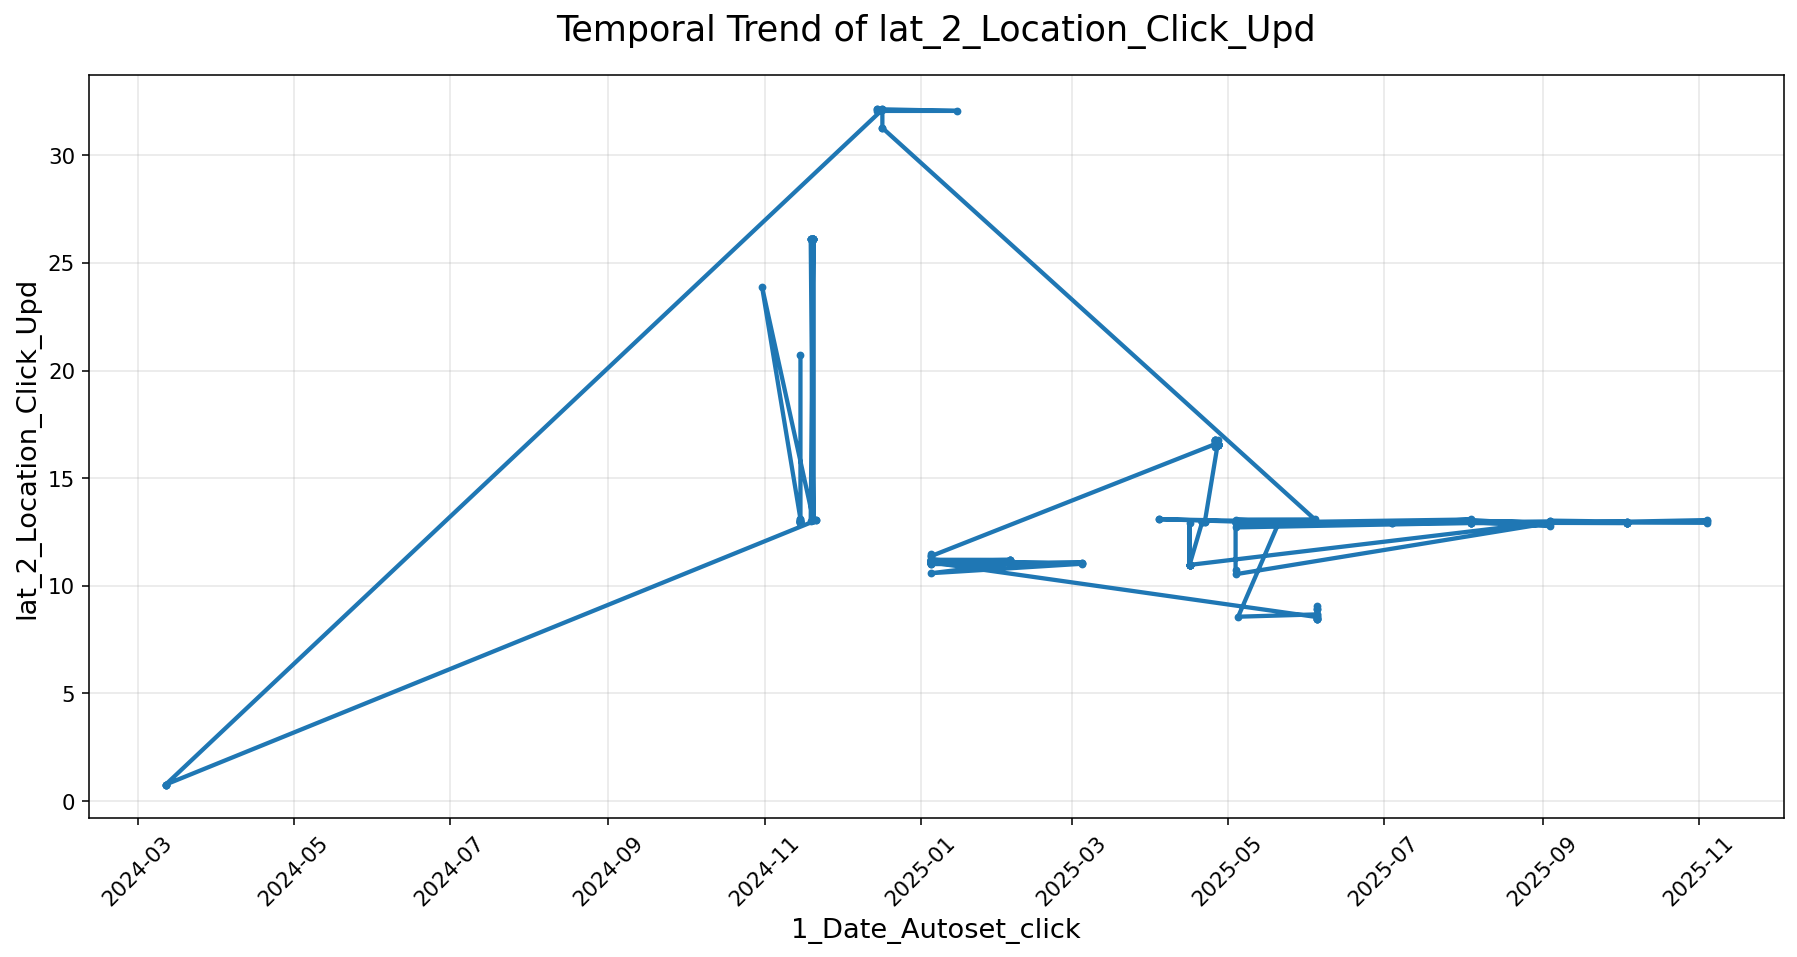

In [16]:
# =========================================================
# 6. TIME SERIES - MATPLOTLIB
# =========================================================
date_col = possible_date_cols[0] if len(possible_date_cols) > 0 else None
ts_col = "TDS" if "TDS" in df.columns else (numeric_cols[0] if numeric_cols else None)

if date_col and ts_col:
    fig, ax = plt.subplots(figsize=(13, 7))
    ax.plot(df[date_col], df[ts_col], linewidth=2.2, marker="o", markersize=3)

    ax.set_title(f"Temporal Trend of {ts_col}", pad=18)
    ax.set_xlabel(date_col)
    ax.set_ylabel(ts_col)
    plt.xticks(rotation=45)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [17]:
# =========================================================
# 7. WQI TREND - MATPLOTLIB
# =========================================================
if "WQI_Simple" in df.columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(df["WQI_Simple"], linewidth=2.2)

    ax.set_title("Simple Water Quality Index Trend", pad=18)
    ax.set_xlabel("Observation Index")
    ax.set_ylabel("WQI Score")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# =========================================================
# 8. INTERACTIVE PLOTLY HEATMAP
# =========================================================
if len(plot_numeric_cols) > 1:
    corr = df[plot_numeric_cols].corr()

    fig = px.imshow(
        corr,
        text_auto=".2f",
        aspect="auto",
        title="Interactive Correlation Heatmap"
    )
    fig.update_layout(
        template="plotly_white",
        width=950,
        height=800,
        title_x=0.5
    )
    fig.show()

In [18]:
# =========================================================
# 9. INTERACTIVE PLOTLY SCATTER
# =========================================================
if scatter_x and scatter_y:
    fig = px.scatter(
        df,
        x=scatter_x,
        y=scatter_y,
        title=f"Interactive Scatter Plot: {scatter_x} vs {scatter_y}",
        opacity=0.75,
        hover_data=df.columns[:8]
    )
    fig.update_layout(
        template="plotly_white",
        width=950,
        height=650,
        title_x=0.5
    )
    fig.show()

In [19]:
# =========================================================
# 10. INTERACTIVE PLOTLY LINE / TIME SERIES
# =========================================================
if date_col and ts_col:
    fig = px.line(
        df,
        x=date_col,
        y=ts_col,
        title=f"Interactive Time-Series: {ts_col} over {date_col}",
        markers=True
    )
    fig.update_layout(
        template="plotly_white",
        width=1000,
        height=650,
        title_x=0.5
    )
    fig.show()

In [21]:
# =========================================================
# 11. INTERACTIVE PLOTLY KDE-STYLE HISTOGRAM
# Plotly doesn't have a direct px.kde convenience like seaborn,
# so this gives an interactive distribution view.
# =========================================================
if len(density_cols) > 0:
    chosen_col = density_cols[0]

    fig = px.histogram(
        df,
        x=chosen_col,
        marginal="box",
        nbins=30,
        title=f"Interactive Distribution View: {chosen_col}"
    )
    fig.update_layout(
        template="plotly_white",
        width=950,
        height=650,
        title_x=0.5
    )
    fig.show()

# =========================================================
# 12. MAP VISUALIZATION - PLOTLY
# Requires latitude and longitude columns
# =========================================================
lat_candidates = [c for c in df.columns if c.lower() in ["lat", "latitude"]]
lon_candidates = [c for c in df.columns if c.lower() in ["lon", "lng", "longitude"]]

if lat_candidates and lon_candidates:
    lat_col = lat_candidates[0]
    lon_col = lon_candidates[0]

    color_col = "WQI_Simple" if "WQI_Simple" in df.columns else (numeric_cols[0] if numeric_cols else None)

    hover_cols = []
    for c in ["pH", "TDS", "Turbidity", "DO"]:
        if c in df.columns:
            hover_cols.append(c)

    map_fig = px.scatter_map(
        df,
        lat=lat_col,
        lon=lon_col,
        color=color_col,
        hover_data=hover_cols if hover_cols else None,
        zoom=4,
        title="Water Quality Sample Locations"
    )

    map_fig.update_layout(
        template="plotly_white",
        width=1000,
        height=700,
        title_x=0.5
    )
    map_fig.show()
else:
    print("\nMap not generated: latitude/longitude columns were not found.")
    print("Expected columns like: lat / latitude and lon / lng / longitude")

print("\nFinal Cleaned Dataset Shape:", df.shape)


Map not generated: latitude/longitude columns were not found.
Expected columns like: lat / latitude and lon / lng / longitude

Final Cleaned Dataset Shape: (250, 139)
